In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Covid_19_Clean_Complete (2).csv")

In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
df.shape

(49068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
df.rename(columns={"Province/State" : "State" , "Country/Region" : "Country"}, inplace=True)

In [ ]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

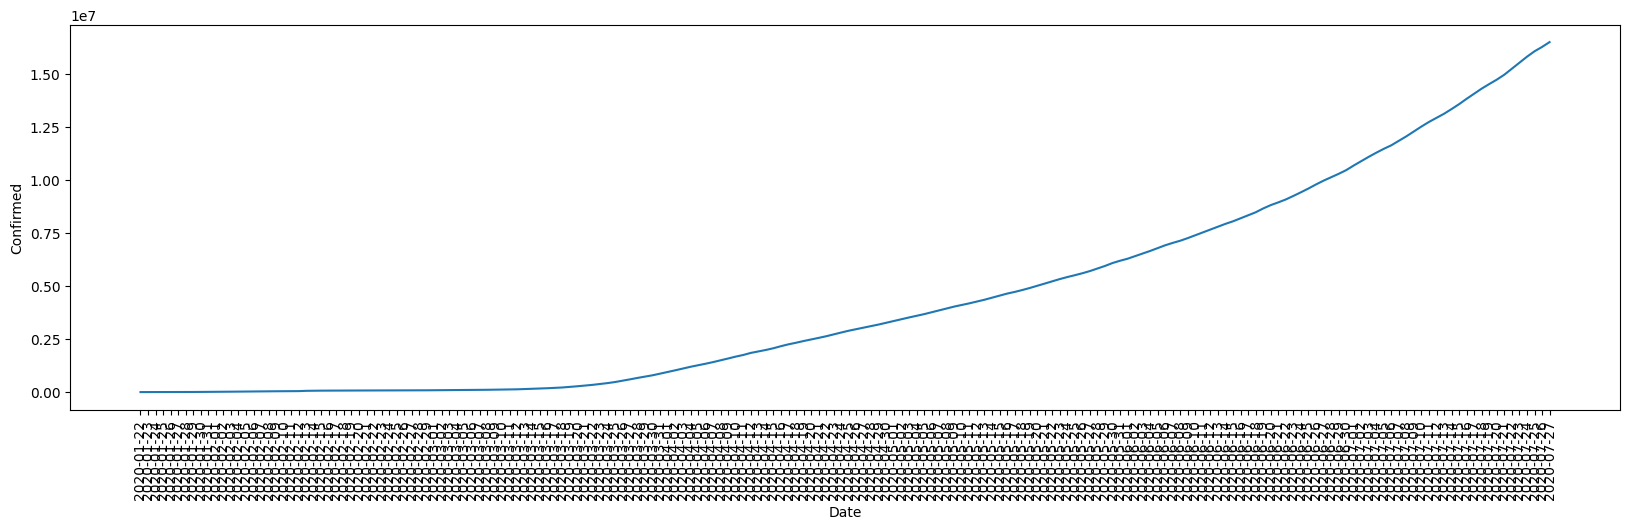

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=confirmed_cases, x="Date", y="Confirmed")
plt.xticks(rotation=90)
plt.show()

In [ ]:
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


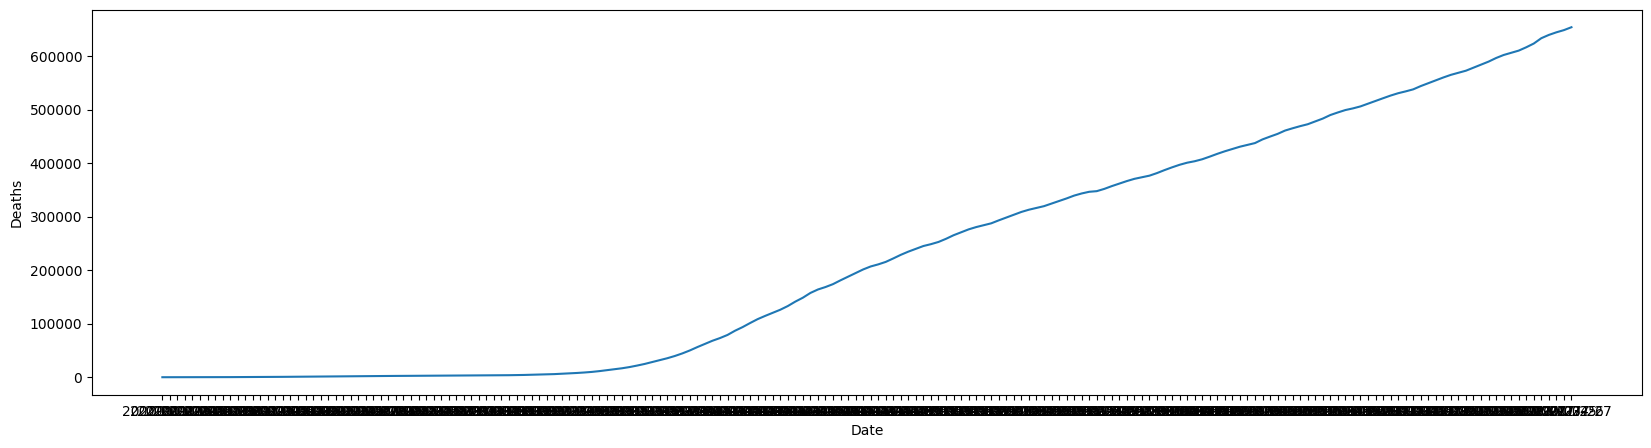

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=death_cases, x="Date", y="Deaths")
plt.show()

In [ ]:
# Let's find the most affected countries

In [ ]:
data_countries = df.groupby("Country")[["Confirmed", "Active", "Recovered", "Deaths"]].sum().reset_index()

In [ ]:
data_countries

,Country,Confirmed,Active,Recovered,Deaths
0,Afghanistan,1936390,1089052,798240,49098
1,Albania,196702,72117,118877,5708
2,Algeria,1179755,345886,755897,77972
3,Andorra,94404,19907,69074,5423
4,Angola,22662,15011,6573,1078
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,61124,1370
183,Western Sahara,901,190,648,63
184,Yemen,67180,25694,23779,17707
185,Zambia,129421,43167,83611,2643


In [ ]:
# Top 3 countries based on confiremed cases ->
top3_confirmed = data_countries.sort_values(by="Confirmed", ascending=False).head(3)

In [ ]:
top3_confirmed

,Country,Confirmed,Active,Recovered,Deaths
173,US,224345948,156981121,56353416,11011411
23,Brazil,89524967,31094060,54492873,3938034
138,Russia,45408411,19668578,25120448,619385


In [ ]:
# Top 3 countries based on death cases ->
top3_deaths = data_countries.sort_values(by="Deaths", ascending=False).head(3)

In [ ]:
top3_deaths

,Country,Confirmed,Active,Recovered,Deaths
173,US,224345948,156981121,56353416,11011411
177,United Kingdom,26748587,22624595,126217,3997775
23,Brazil,89524967,31094060,54492873,3938034


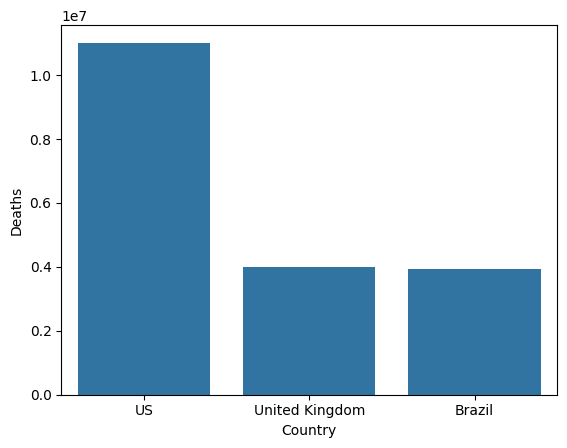

In [ ]:
sns.barplot(data=top3_deaths, x="Country", y="Deaths")
plt.show()

In [ ]:
us = df[df["Country"] == "US"]

In [ ]:
us

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [ ]:
data_us = us.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()

In [ ]:
data_us

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,1,0,1,0
1,2020-01-23,1,0,1,0
2,2020-01-24,2,0,2,0
3,2020-01-25,2,0,2,0
4,2020-01-26,5,0,5,0
...,...,...,...,...,...
183,2020-07-23,4038816,144430,2661117,1233269
184,2020-07-24,4112531,145560,2705347,1261624
185,2020-07-25,4178970,146465,2753091,1279414
186,2020-07-26,4233923,146935,2789125,1297863


In [ ]:
brazil = df[df["Country"] == "Brazil"]
brazil

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,2020-01-22,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,2020-01-23,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,2020-01-24,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,2020-01-25,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,2020-01-26,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,2020-07-23,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,2020-07-24,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,2020-07-25,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,2020-07-26,2419091,87004,1812913,519174,Americas


In [ ]:
data_brazil = brazil.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()
data_brazil

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,583080,1620313
184,2020-07-24,2343366,85238,564914,1693214
185,2020-07-25,2394513,86449,522705,1785359
186,2020-07-26,2419091,87004,519174,1812913


In [ ]:
russ = df[df["Country"] == "Russia"]
russ

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,2020-01-22,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,2020-01-23,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,2020-01-24,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,2020-01-25,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,2020-01-26,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,2020-07-23,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,2020-07-24,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,2020-07-25,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,2020-07-26,811073,13249,599172,198652,Europe


In [ ]:
data_russ = russ.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()
data_russ

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,201552,579295
184,2020-07-24,799499,13026,198745,587728
185,2020-07-25,805332,13172,196096,596064
186,2020-07-26,811073,13249,198652,599172


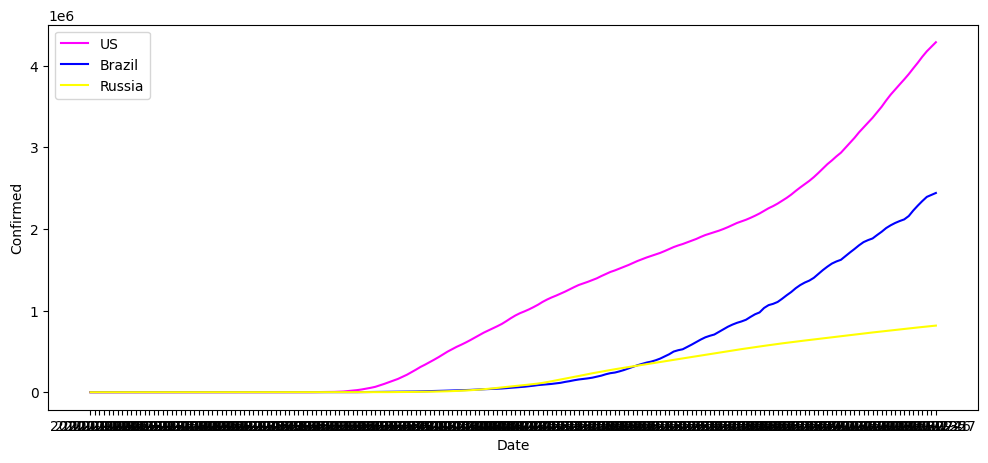

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=data_us, x="Date", y="Confirmed", color="magenta", label="US")
sns.lineplot(data=data_brazil, x="Date", y="Confirmed", color="blue", label="Brazil")
sns.lineplot(data=data_russ, x="Date", y="Confirmed", color="yellow", label="Russia")
plt.show()

,Country,Confirmed,Active,Recovered,Deaths
173,US,224345948,156981121,56353416,11011411
23,Brazil,89524967,31094060,54492873,3938034
177,United Kingdom,26748587,22624595,126217,3997775


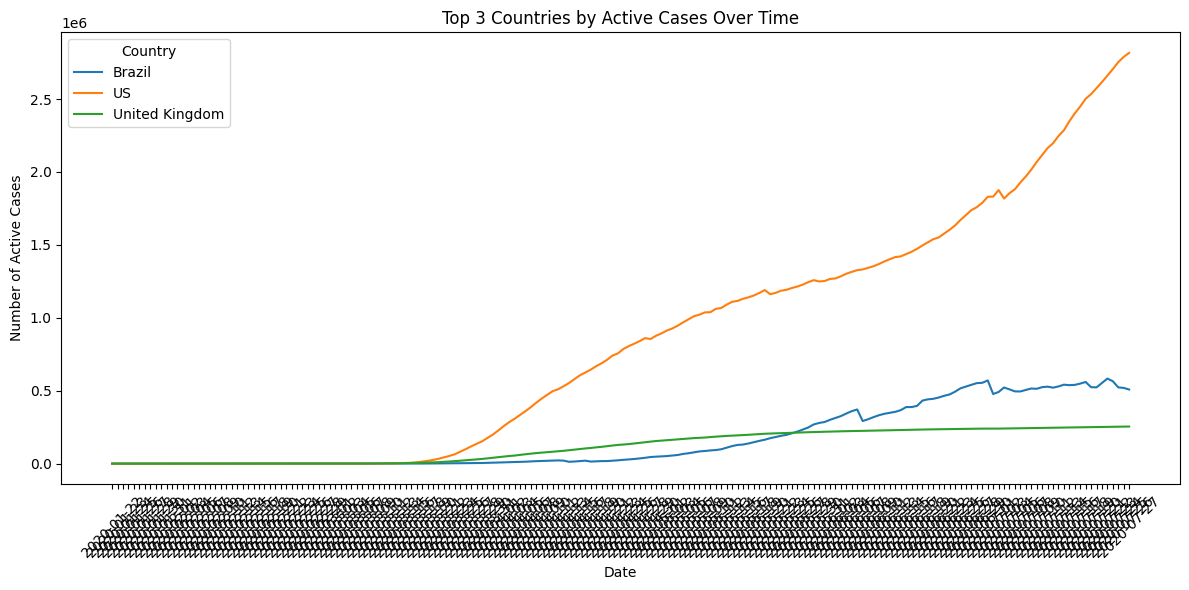

In [ ]:
top3_active = data_countries.sort_values(by="Active", ascending=False).head(3)
display(top3_active)

top3_active_countries = top3_active['Country'].tolist()
active_data_top3 = df[df['Country'].isin(top3_active_countries)]
active_data_top3_grouped = active_data_top3.groupby(['Date', 'Country'])['Active'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=active_data_top3_grouped, x="Date", y="Active", hue="Country")
plt.title('Top 3 Countries by Active Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Country,Confirmed,Active,Recovered,Deaths
173,US,224345948,156981121,56353416,11011411
177,United Kingdom,26748587,22624595,126217,3997775
23,Brazil,89524967,31094060,54492873,3938034


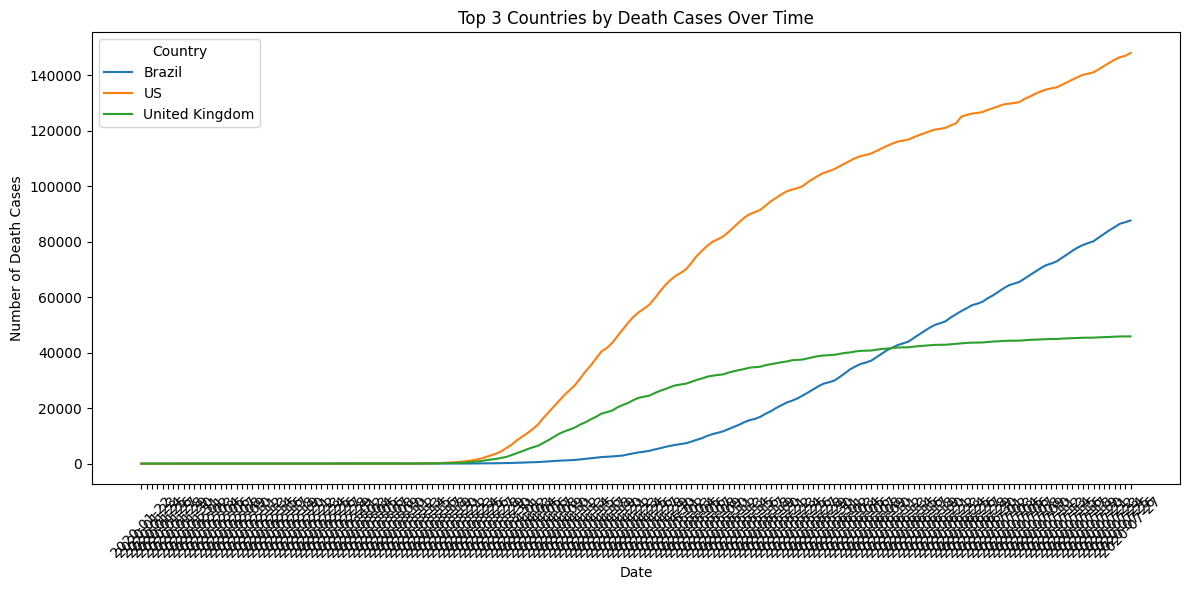

In [ ]:
top3_deaths = data_countries.sort_values(by="Deaths", ascending=False).head(3)
display(top3_deaths)

top3_deaths_countries = top3_deaths['Country'].tolist()
deaths_data_top3 = df[df['Country'].isin(top3_deaths_countries)]
deaths_data_top3_grouped = deaths_data_top3.groupby(['Date', 'Country'])['Deaths'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=deaths_data_top3_grouped, x="Date", y="Deaths", hue="Country")
plt.title('Top 3 Countries by Death Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Death Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Country,Confirmed,Active,Recovered,Deaths
173,US,224345948,156981121,56353416,11011411
23,Brazil,89524967,31094060,54492873,3938034
138,Russia,45408411,19668578,25120448,619385


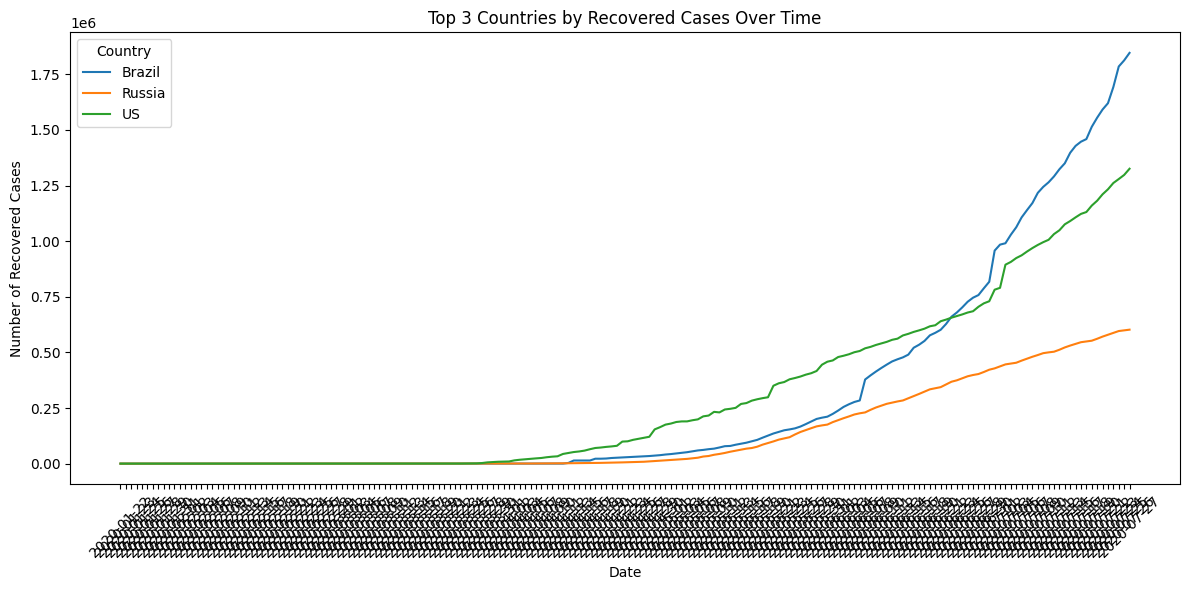

In [ ]:
top3_recovered = data_countries.sort_values(by="Recovered", ascending=False).head(3)
display(top3_recovered)

top3_recovered_countries = top3_recovered['Country'].tolist()
recovered_data_top3 = df[df['Country'].isin(top3_recovered_countries)]
recovered_data_top3_grouped = recovered_data_top3.groupby(['Date', 'Country'])['Recovered'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=recovered_data_top3_grouped, x="Date", y="Recovered", hue="Country")
plt.title('Top 3 Countries by Recovered Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Recovered Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
# Forcasting for the confiremed cases

In [ ]:
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()

In [ ]:
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
# We need to rename the column as ds(datestamp) and y(value)
prophet_data = confirmed_cases.rename(columns={"Date" : "ds", "Confirmed" : "y"})
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
model = Prophet()

In [ ]:
model.fit(prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=7)       # For future 7 days
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.317896e+05,8.550942e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.176972e+05,1.002944e+05,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.308830e+04,1.081537e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-8.638798e+04,1.162407e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-1.001780e+05,1.129074e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663968e+07,1.685331e+07,1.673945e+07,1.674981e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685608e+07,1.706631e+07,1.693761e+07,1.696045e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705528e+07,1.726876e+07,1.713296e+07,1.717253e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725424e+07,1.747272e+07,1.732826e+07,1.738589e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forecast[["yhat_lower", "yhat_upper", "yhat"]]

,yhat_lower,yhat_upper,yhat
0,-1.317896e+05,8.550942e+04,-2.067685e+04
1,-1.176972e+05,1.002944e+05,-8.050953e+03
2,-9.308830e+04,1.081537e+05,5.827449e+03
3,-8.638798e+04,1.162407e+05,1.217668e+04
4,-1.001780e+05,1.129074e+05,8.405020e+03
...,...,...,...
190,1.663968e+07,1.685331e+07,1.674392e+07
191,1.685608e+07,1.706631e+07,1.695911e+07
192,1.705528e+07,1.726876e+07,1.716677e+07
193,1.725424e+07,1.747272e+07,1.736430e+07


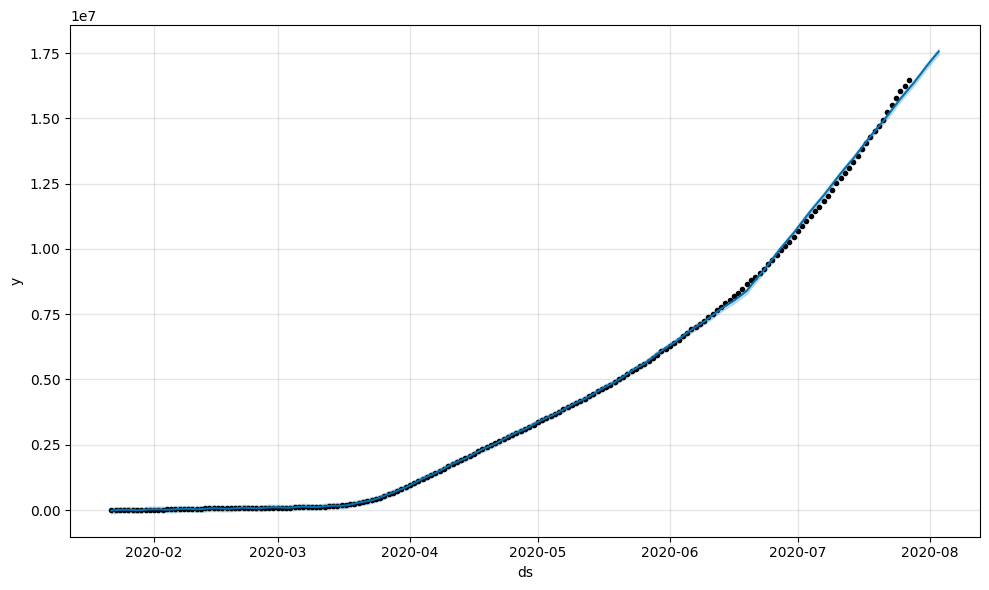

In [ ]:
model.plot(forecast)
plt.show()

### Forecasting for Active Cases

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat_lower,yhat_upper,yhat
185,2020-07-25,6.130253e+06,6.222238e+06,6.175613e+06
186,2020-07-26,6.197796e+06,6.287778e+06,6.242904e+06
187,2020-07-27,6.252891e+06,6.342865e+06,6.296654e+06
188,2020-07-28,6.303742e+06,6.401170e+06,6.353420e+06
189,2020-07-29,6.366983e+06,6.465556e+06,6.415820e+06
190,2020-07-30,6.433789e+06,6.524590e+06,6.481279e+06
191,2020-07-31,6.501822e+06,6.594647e+06,6.549320e+06
192,2020-08-01,6.568217e+06,6.657890e+06,6.611485e+06
193,2020-08-02,6.629489e+06,6.727812e+06,6.678776e+06
194,2020-08-03,6.679489e+06,6.783301e+06,6.732526e+06


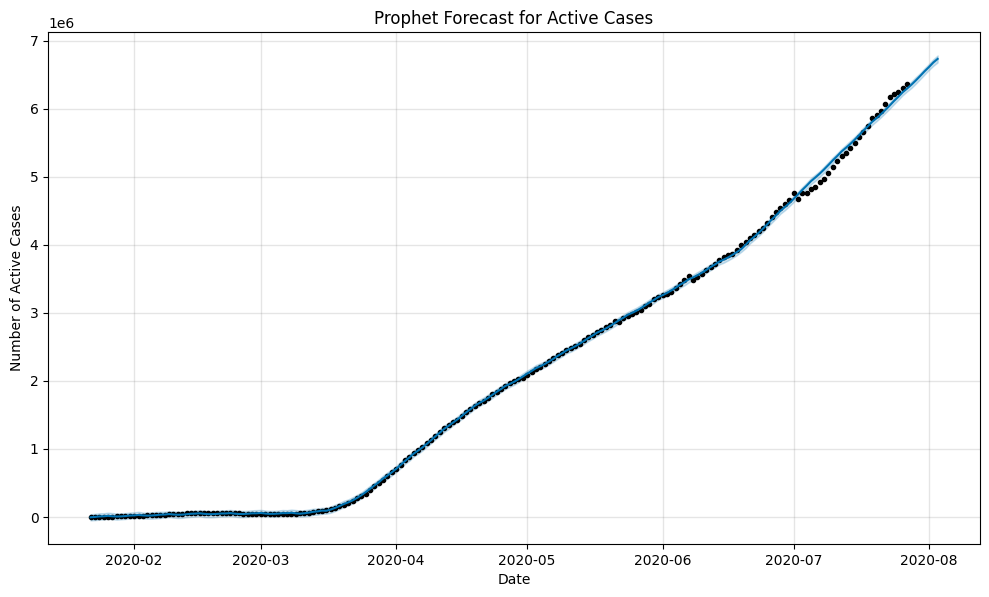

In [ ]:
active_cases = df.groupby(["Date"])["Active"].sum().reset_index()
prophet_active_data = active_cases.rename(columns={"Date" : "ds", "Active" : "y"})

model_active = Prophet()
model_active.fit(prophet_active_data)

future_active = model_active.make_future_dataframe(periods=7)
forecast_active = model_active.predict(future_active)

display(forecast_active[["ds", "yhat_lower", "yhat_upper", "yhat"]].tail(10))
model_active.plot(forecast_active)
plt.title('Prophet Forecast for Active Cases')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.show()

### Forecasting for Death Cases

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat_lower,yhat_upper,yhat
185,2020-07-25,636763.709156,640645.182622,638682.579028
186,2020-07-26,640923.328228,644899.533439,642819.498044
187,2020-07-27,645110.841367,649141.784492,647109.813166
188,2020-07-28,650231.936858,654277.822340,652315.573266
189,2020-07-29,655901.709908,659995.855739,657882.137569
190,2020-07-30,661400.174296,665464.532753,663491.406328
191,2020-07-31,666611.856445,670936.724180,669006.407283
192,2020-08-01,671552.885850,676102.582238,673888.441609
193,2020-08-02,675335.492131,680373.720423,678025.360624
194,2020-08-03,679211.040738,685033.890953,682315.675746


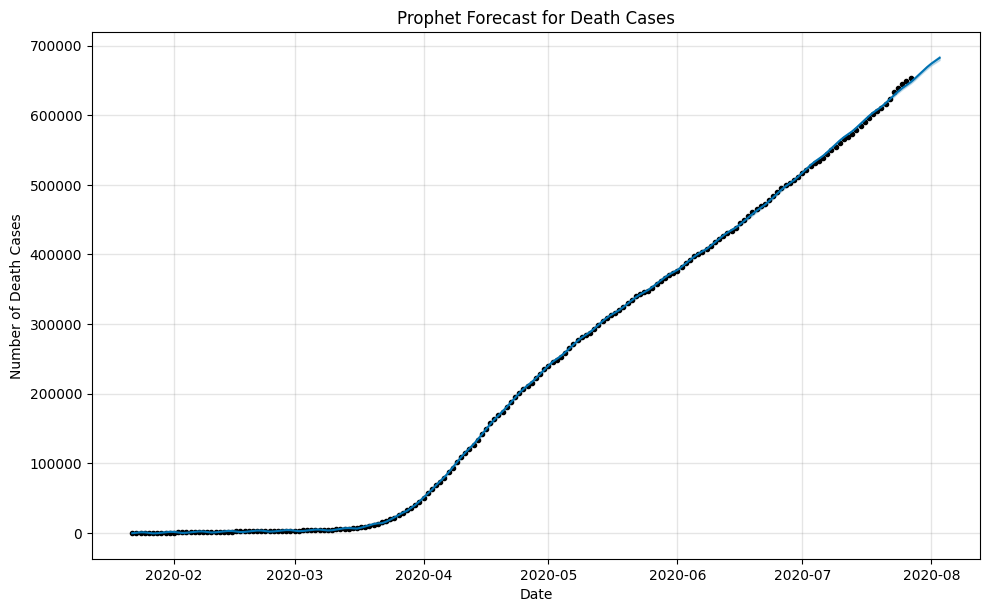

In [ ]:
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()
prophet_death_data = death_cases.rename(columns={"Date" : "ds", "Deaths" : "y"})

model_death = Prophet()
model_death.fit(prophet_death_data)

future_death = model_death.make_future_dataframe(periods=7)
forecast_death = model_death.predict(future_death)

display(forecast_death[["ds", "yhat_lower", "yhat_upper", "yhat"]].tail(10))
model_death.plot(forecast_death)
plt.title('Prophet Forecast for Death Cases')
plt.xlabel('Date')
plt.ylabel('Number of Death Cases')
plt.show()

### Forecasting for Recovered Cases

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat_lower,yhat_upper,yhat
185,2020-07-25,8.838639e+06,8.996617e+06,8.921448e+06
186,2020-07-26,8.967159e+06,9.125136e+06,9.047423e+06
187,2020-07-27,9.108375e+06,9.266428e+06,9.183923e+06
188,2020-07-28,9.234650e+06,9.385183e+06,9.311038e+06
189,2020-07-29,9.373098e+06,9.532651e+06,9.453140e+06
190,2020-07-30,9.511307e+06,9.675435e+06,9.595793e+06
191,2020-07-31,9.656655e+06,9.818175e+06,9.737193e+06
192,2020-08-01,9.796227e+06,9.957122e+06,9.877354e+06
193,2020-08-02,9.917485e+06,1.008956e+07,1.000333e+07
194,2020-08-03,1.005315e+07,1.022198e+07,1.013983e+07


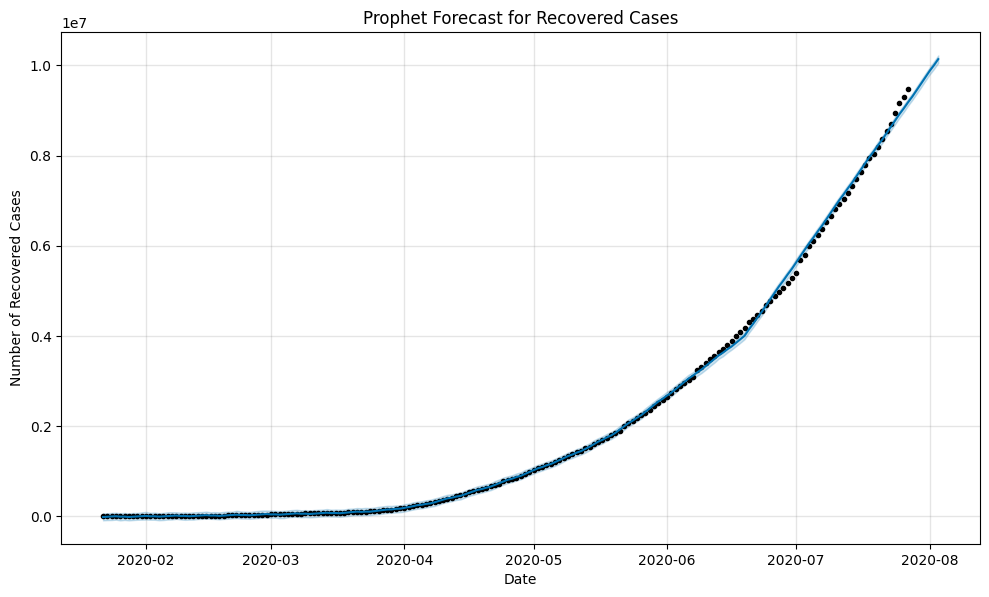

In [ ]:
recovered_cases = df.groupby(["Date"])["Recovered"].sum().reset_index()
prophet_recovered_data = recovered_cases.rename(columns={"Date" : "ds", "Recovered" : "y"})

model_recovered = Prophet()
model_recovered.fit(prophet_recovered_data)

future_recovered = model_recovered.make_future_dataframe(periods=7)
forecast_recovered = model_recovered.predict(future_recovered)

display(forecast_recovered[["ds", "yhat_lower", "yhat_upper", "yhat"]].tail(10))
model_recovered.plot(forecast_recovered)
plt.title('Prophet Forecast for Recovered Cases')
plt.xlabel('Date')
plt.ylabel('Number of Recovered Cases')
plt.show()